Kelompok 5

Tahap 1: Instalasi Library dan Persiapan

In [ ]:
# Instalasi library yang dibutuhkan
!pip install networkx python-louvain pandas numpy matplotlib
!pip install python-louvain
# Import Library
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import community as community_louvain # Untuk algoritma Louvain
from networkx.algorithms import bipartite
import requests
import io
import sys
print("Library berhasil diimpor.")

Library berhasil diimpor.


Tahap 2: Pengambilan Data dan Preprocessing

In [ ]:
# URL Dataset Moreno Crime Network dari KONECT
url = "http://konect.cc/files/download.tsv.moreno_crime.tar.bz2"

print("Mengunduh dataset...")
try:
    # Download file
    response = requests.get(url)
    response.raise_for_status()

    # Baca file .tar.bz2 langsung ke dalam memory
    import tarfile
    tar = tarfile.open(fileobj=io.BytesIO(response.content), mode="r:bz2")

    # Ekstrak file spesifik (out.moreno_crime)
    # KONECT format biasanya memiliki beberapa file, kita ambil file edgelist utamanya
    member = [m for m in tar.getmembers() if "out.moreno_crime" in m.name][0]
    f = tar.extractfile(member)

    # PERBAIKAN: Membaca dengan separator spasi (\s+) dan header None
    # KONECT format standar seringkali memiliki 3 kolom: Source Target Weight
    df = pd.read_csv(f, sep='\s+', comment='%', header=None, engine='python')

    # Debug: Cek jumlah kolom yang terbaca
    print(f"Jumlah kolom terdeteksi: {df.shape[1]}")

    # Penanganan Dinamis Kolom
    if df.shape[1] == 2:
        df.columns = ['Person_ID', 'Crime_ID']
    elif df.shape[1] >= 3:
        # Jika ada 3 kolom atau lebih, ambil 2 kolom pertama (Source, Target) dan abaikan sisanya (Weight)
        df = df.iloc[:, :2]
        df.columns = ['Person_ID', 'Crime_ID']
        print("Info: Dataset memiliki kolom tambahan (weight), kolom tersebut diabaikan untuk analisis ini.")

    print("Dataset berhasil dimuat.")
    print(f"Jumlah baris data (edges awal): {len(df)}")
    print(df.head())

except Exception as e:
    print(f"Gagal memproses data: {e}")

<>:21: SyntaxWarning: invalid escape sequence '\s'
<>:21: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_4870/1496416724.py:21: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(f, sep='\s+', comment='%', header=None, engine='python')


Mengunduh dataset...
Jumlah kolom terdeteksi: 2
Dataset berhasil dimuat.
Jumlah baris data (edges awal): 1476
   Person_ID  Crime_ID
0          1         1
1          1         2
2          1         3
3          1         4
4          2         5


Tahap 3: Pembentukan Jaringan (Proyeksi Bipartite)

In [ ]:
# --- KODE PERBAIKAN: MEMISAHKAN ID PELAKU DAN KASUS ---

# 1. Reset Graph
B = nx.Graph()

# 2. Tambahkan Prefix (Awalan) unik untuk membedakan ID
# 'p' untuk Person (Pelaku), 'c' untuk Crime (Kasus)
# Contoh: ID 1 -> 'p1' (Pelaku) dan 'c1' (Kasus)
person_nodes = ['p' + str(pid) for pid in df['Person_ID'].unique()]
crime_nodes = ['c' + str(cid) for cid in df['Crime_ID'].unique()]

# 3. Siapkan Edges dengan ID yang sudah diberi prefix
# Tuple format: ('p1', 'c1')
edges_fixed = [('p' + str(row.Person_ID), 'c' + str(row.Crime_ID)) for row in df.itertuples(index=False)]

# 4. Bangun ulang Graph Bipartite
print("Membangun ulang jaringan dengan ID unik (Prefix p/c)...")
B.add_nodes_from(person_nodes, bipartite=0)
B.add_nodes_from(crime_nodes, bipartite=1)
B.add_edges_from(edges_fixed)

print(f"Jumlah Node Bipartite (TOTAL): {B.number_of_nodes()}")
print(f"Jumlah Edge Bipartite: {B.number_of_edges()}")

# 5. Proyeksi Ulang ke One-Mode Network
print("\nMelakukan proyeksi jaringan (Person-Person)...")
person_set = set(n for n, d in B.nodes(data=True) if d['bipartite'] == 0)

# Weighted Projection
G = bipartite.weighted_projected_graph(B, person_set)

print("Proyeksi selesai.")
print(f"Jumlah Node (Pelaku): {G.number_of_nodes()}")
print(f"Jumlah Edge (Hubungan): {G.number_of_edges()}")

Membangun ulang jaringan dengan ID unik (Prefix p/c)...
Jumlah Node Bipartite (TOTAL): 1380
Jumlah Edge Bipartite: 1476

Melakukan proyeksi jaringan (Person-Person)...
Proyeksi selesai.
Jumlah Node (Pelaku): 829
Jumlah Edge (Hubungan): 2253


Tahap 4: Analisis Struktur Jaringan (Metrik Global)

In [ ]:
# Ambil Giant Component (komponen terbesar) untuk perhitungan Diameter
# (Diameter hanya bisa dihitung pada graf yang terhubung penuh)
largest_cc = max(nx.connected_components(G), key=len)
G_giant = G.subgraph(largest_cc).copy()

print("=== Deskripsi Awal Struktur Jaringan ===")
print(f"Jumlah Node Total: {G.number_of_nodes()}")
print(f"Jumlah Edge Total: {G.number_of_edges()}")
print(f"Density: {nx.density(G):.6f}")
print(f"Jumlah Komponen Terhubung: {nx.number_connected_components(G)}")
print(f"Ukuran Giant Component: {len(largest_cc)} nodes")

# Diameter (hanya pada Giant Component)
try:
    diam = nx.diameter(G_giant)
    print(f"Diameter (Giant Component): {diam}")
except:
    print("Diameter tidak dapat dihitung (graf kosong).")

# Average Clustering Coefficient
avg_clust = nx.average_clustering(G)
print(f"Average Clustering Coefficient: {avg_clust:.4f}")

=== Deskripsi Awal Struktur Jaringan ===
Jumlah Node Total: 829
Jumlah Edge Total: 2253
Density: 0.006565
Jumlah Komponen Terhubung: 20
Ukuran Giant Component: 754 nodes
Diameter (Giant Component): 16
Average Clustering Coefficient: 0.7191


Tahap 5: Perhitungan Metrik Sentralitas

In [ ]:
print("Menghitung Metrik Sentralitas... (mungkin butuh beberapa detik)")

# 1. Degree Centrality
deg_cent = nx.degree_centrality(G)
# 2. Betweenness Centrality
bet_cent = nx.betweenness_centrality(G, normalized=True)
# 3. Closeness Centrality
clo_cent = nx.closeness_centrality(G)
# 4. Eigenvector Centrality
eig_cent = nx.eigenvector_centrality(G, max_iter=1000)
# 5. PageRank
pagerank = nx.pagerank(G)

# Buat DataFrame untuk memudahkan sorting dan tampilan
df_metrics = pd.DataFrame({
    'Degree': deg_cent,
    'Betweenness': bet_cent,
    'Closeness': clo_cent,
    'Eigenvector': eig_cent,
    'PageRank': pagerank
})

print("=== Top 5 Node Berdasarkan Degree Centrality ===")
display(df_metrics.sort_values(by='Degree', ascending=False).head(5))

print("\n=== Top 5 Node Berdasarkan Betweenness Centrality ===")
display(df_metrics.sort_values(by='Betweenness', ascending=False).head(5))

Menghitung Metrik Sentralitas... (mungkin butuh beberapa detik)
=== Top 5 Node Berdasarkan Degree Centrality ===


,Degree,Betweenness,Closeness,Eigenvector,PageRank
p425,0.061594,0.124184,0.190644,0.307693,0.007265
p2,0.057971,0.186898,0.197518,0.013428,0.009270
p356,0.053140,0.118532,0.195432,0.008411,0.007546
p56,0.039855,0.156948,0.178844,0.214882,0.005687
p695,0.039855,0.040692,0.186186,0.260809,0.004630



=== Top 5 Node Berdasarkan Betweenness Centrality ===


,Degree,Betweenness,Closeness,Eigenvector,PageRank
p815,0.032609,0.349633,0.197290,0.000100,0.007966
p690,0.013285,0.250543,0.199068,0.001400,0.002787
p2,0.057971,0.186898,0.197518,0.013428,0.009270
p56,0.039855,0.156948,0.178844,0.214882,0.005687
p715,0.035024,0.154221,0.196610,0.225446,0.004749


Tahap 6: Deteksi Komunitas & Simulasi Difusi

In [ ]:
# Hapus modul 'community' dari memori jika sudah ada
if 'community' in sys.modules:
    del sys.modules['community']

# --- LANJUTKAN PROSES DETEKSI KOMUNITAS ---

# 1. Deteksi Komunitas (Louvain Method)
partition = community_louvain.best_partition(G)
# Tambahkan atribut komunitas ke node
nx.set_node_attributes(G, partition, 'community')

community_count = len(set(partition.values()))
print(f"=== Deteksi Komunitas ===")
print(f"Jumlah Komunitas Terdeteksi: {community_count}")
print(f"Modularity Score: {community_louvain.modularity(partition, G):.4f}")

# 2. Simulasi Difusi Sederhana
def simple_diffusion_simulation(graph, seed_nodes, threshold=0.3):
    infected = set(seed_nodes)
    newly_infected = set(seed_nodes)
    steps = 0

    while newly_infected:
        steps += 1
        to_infect = set()
        for node in graph.nodes():
            if node not in infected:
                neighbors = set(graph.neighbors(node))
                infected_neighbors = len(neighbors.intersection(infected))
                total_neighbors = len(neighbors)

                if total_neighbors > 0 and (infected_neighbors / total_neighbors) >= threshold:
                    to_infect.add(node)

        if not to_infect:
            break
        infected.update(to_infect)
        newly_infected = to_infect

    return len(infected), steps

# Ambil Top 3 Degree Centrality sebagai Seed Node
top_3_seeds = df_metrics.sort_values(by='Degree', ascending=False).index[:3].tolist()
infected_count, steps = simple_diffusion_simulation(G, top_3_seeds)

print(f"\n=== Simulasi Difusi Awal ===")
print(f"Seed Nodes (Top 3 Influencers): {top_3_seeds}")
print(f"Total Node Terinfeksi: {infected_count} dari {G.number_of_nodes()}")
print(f"Langkah Simulasi: {steps}")

=== Deteksi Komunitas ===
Jumlah Komunitas Terdeteksi: 46
Modularity Score: 0.8778

=== Simulasi Difusi Awal ===
Seed Nodes (Top 3 Influencers): ['p425', 'p2', 'p356']
Total Node Terinfeksi: 32 dari 829
Langkah Simulasi: 4


Tahap 7: Visualisasi Jaringan

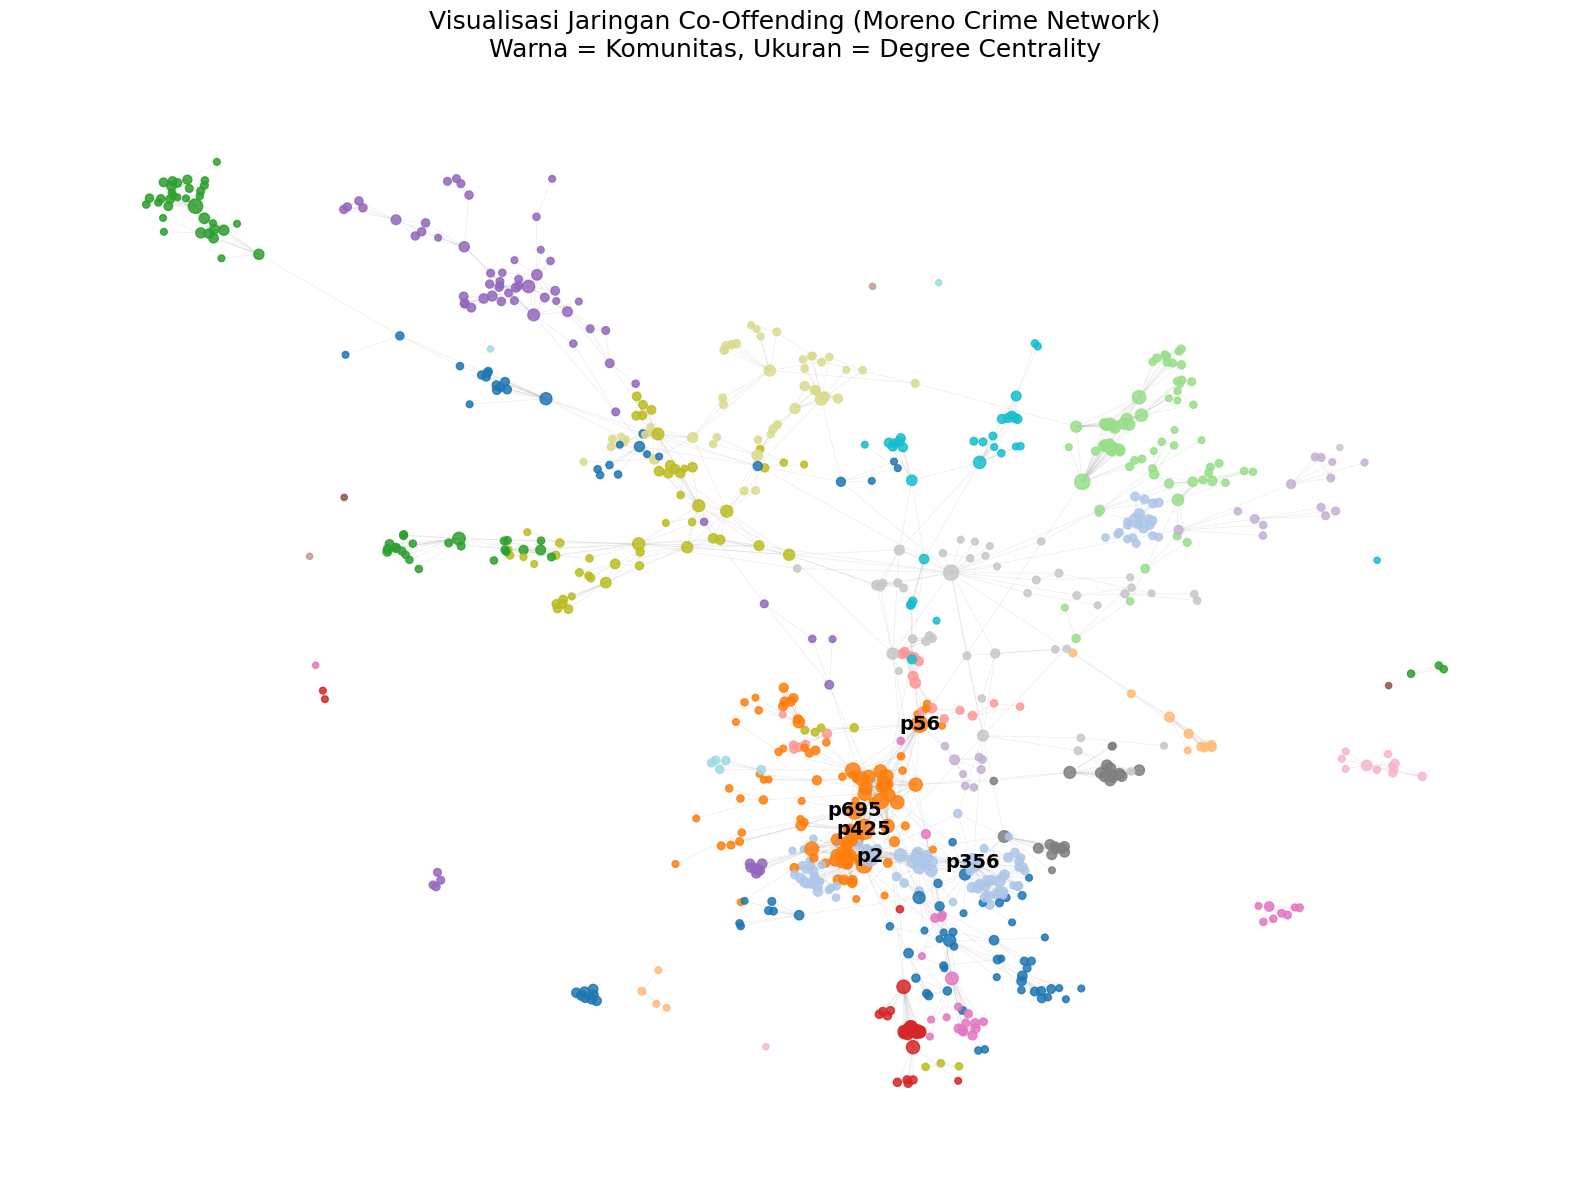

In [ ]:
plt.figure(figsize=(16, 12))

# Posisi node (Layout Fruchterman-Reingold)
# Kita gunakan seed agar bentuk grafik konsisten
pos = nx.spring_layout(G, k=0.1, iterations=50, seed=42)

# Warna berdasarkan komunitas (menggunakan variabel 'partition' dari hasil Tahap 6)
colors = [partition[n] for n in G.nodes()]

# Ukuran node berdasarkan Degree Centrality (agar yang penting terlihat besar)
sizes = [v * 3000 + 20 for v in deg_cent.values()]

# Gambar nodes
nx.draw_networkx_nodes(G, pos, node_size=sizes, node_color=colors, cmap=plt.cm.tab20, alpha=0.85)

# Gambar edges
nx.draw_networkx_edges(G, pos, alpha=0.15, edge_color='gray', width=0.5)

# Gambar labels (hanya untuk Top 5 Degree agar gambar tidak terlalu ramai)
top_nodes = df_metrics.sort_values(by='Degree', ascending=False).index[:5]
labels = {n: str(n) for n in top_nodes}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=14, font_color='black', font_weight='bold')

plt.title("Visualisasi Jaringan Co-Offending (Moreno Crime Network)\nWarna = Komunitas, Ukuran = Degree Centrality", fontsize=18)
plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
print("=== SIMULASI DISRUPSI JARINGAN (Network Robustness) ===")

# Target: Node dengan Betweenness Tertinggi (P815)
target_node = 'p815'

# 1. Kondisi Awal (Sebelum Penghapusan)
initial_gc_size = len(max(nx.connected_components(G), key=len))
initial_components = nx.number_connected_components(G)

print(f"Kondisi Awal:")
print(f"- Ukuran Giant Component: {initial_gc_size} nodes")
print(f"- Jumlah Komponen Terpisah: {initial_components}")

# 2. Simulasi Penghapusan Node (Disrupsi)
G_disrupted = G.copy()
G_disrupted.remove_node(target_node)

# 3. Kondisi Akhir (Setelah Penghapusan)
disrupted_gc_size = len(max(nx.connected_components(G_disrupted), key=len))
disrupted_components = nx.number_connected_components(G_disrupted)

print(f"\nKondisi Setelah Penghapusan Node {target_node}:")
print(f"- Ukuran Giant Component: {disrupted_gc_size} nodes (Turun {initial_gc_size - disrupted_gc_size} node)")
print(f"- Jumlah Komponen Terpisah: {disrupted_components} (Naik {disrupted_components - initial_components} komponen)")

# Interpretasi untuk Laporan
drop_percentage = ((initial_gc_size - disrupted_gc_size) / initial_gc_size) * 100
print(f"\n>>> Temuan: Penghapusan node {target_node} menyebabkan penurunan ukuran jaringan terbesar sebesar {drop_percentage:.2f}% dan memecah jaringan menjadi {disrupted_components} bagian.")

=== SIMULASI DISRUPSI JARINGAN (Network Robustness) ===
Kondisi Awal:
- Ukuran Giant Component: 754 nodes
- Jumlah Komponen Terpisah: 20

Kondisi Setelah Penghapusan Node p815:
- Ukuran Giant Component: 712 nodes (Turun 42 node)
- Jumlah Komponen Terpisah: 31 (Naik 11 komponen)

>>> Temuan: Penghapusan node p815 menyebabkan penurunan ukuran jaringan terbesar sebesar 5.57% dan memecah jaringan menjadi 31 bagian.
